In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
sentiment = pd.read_csv('/fear_greed.csv')
trades = pd.read_csv('/historical_data.csv')

print("Sentiment Dataset")
print(sentiment.head())

print("\nTrader Dataset")
print(trades.head())

Sentiment Dataset
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Dataset
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09

In [4]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [5]:
print("Missing Values in Sentiment Dataset")
print(sentiment.isnull().sum())

print("\nMissing Values in Trades Dataset")
print(trades.isnull().sum())

Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trades Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("Duplicate Rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate Rows in Trades:", trades.duplicated().sum())

Duplicate Rows in Sentiment: 0
Duplicate Rows in Trades: 0


In [7]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['time'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

print("Date conversion successful")

Date conversion successful


In [13]:
merged = pd.merge(trades, sentiment, on='date', how='left')
merged['win'] = merged['Closed PnL'] > 0

print(merged[['Closed PnL', 'win']].head())

   Closed PnL    win
0         0.0  False
1         0.0  False
2         0.0  False
3         0.0  False
4         0.0  False


In [15]:
daily_pnl = merged.groupby(
    ['Account', 'date']
)['Closed PnL'].sum().reset_index()

print(daily_pnl.head())

                                      Account        date  Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1


In [17]:
win_rate = merged.groupby('Account')['win'].mean().reset_index()

win_rate.columns = ['Account', 'win_rate']

print(win_rate.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [19]:
trades_per_day = merged.groupby(
    ['date', 'classification']
).size().reset_index(name='trade_count')

print(trades_per_day.head())

         date classification  trade_count
0  2023-05-01          Greed            3
1  2023-12-05  Extreme Greed            9
2  2023-12-14          Greed           11
3  2023-12-15          Greed            2
4  2023-12-16          Greed            3


In [21]:
print(merged['Side'].unique())

['BUY' 'SELL']


In [27]:
long_short = merged.groupby(
    ['classification', 'Side']
).size().reset_index(name='count')

print(long_short)

  classification  Side  count
0   Extreme Fear   BUY  10935
1   Extreme Fear  SELL  10465
2  Extreme Greed   BUY  17940
3  Extreme Greed  SELL  22052
4           Fear   BUY  30270
5           Fear  SELL  31567
6          Greed   BUY  24576
7          Greed  SELL  25727
8        Neutral   BUY  18969
9        Neutral  SELL  18717


In [23]:
print(merged['leverage'].describe())

KeyError: 'leverage'

In [26]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date', 'timestamp', 'value', 'classification',
       'win'],
      dtype='object')


In [28]:
performance = merged.groupby('classification').agg({
    'Closed PnL': ['mean', 'median'],
    'win': 'mean'
})

print(performance)

               Closed PnL              win
                     mean median      mean
classification                            
Extreme Fear    34.537862    0.0  0.370607
Extreme Greed   67.892861    0.0  0.464943
Fear            54.290400    0.0  0.420768
Greed           42.743559    0.0  0.384828
Neutral         34.307718    0.0  0.396991


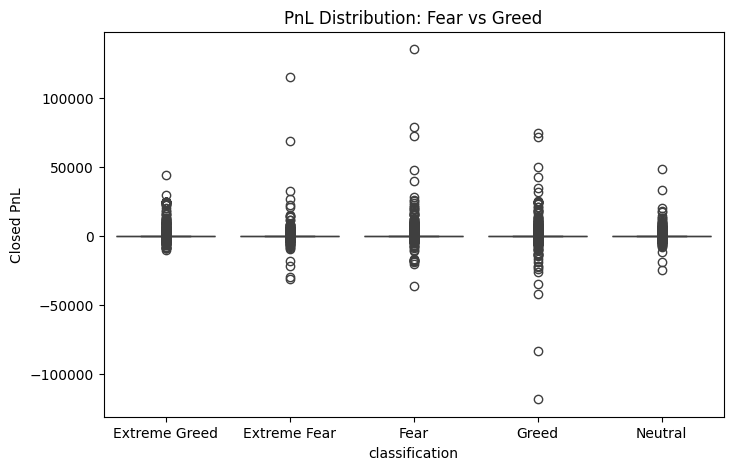

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution: Fear vs Greed')
plt.savefig('PnL Distribution: Fear vs Greed')
plt.show()

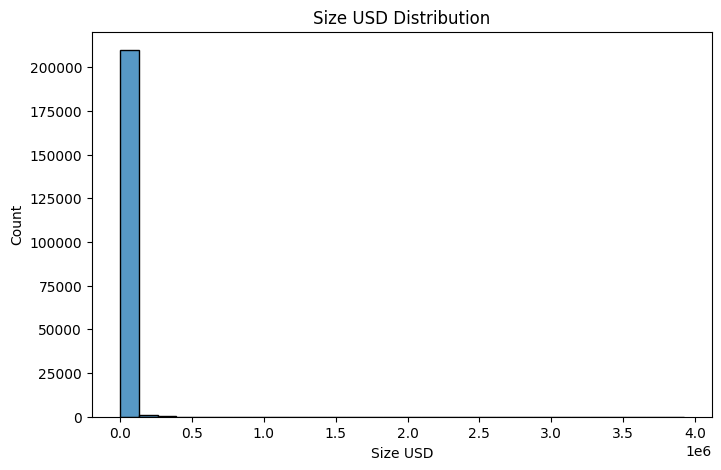

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged['Size USD'],
    bins=30
)

plt.title('Size USD Distribution')
plt.savefig('size USD Distribution')
plt.show()

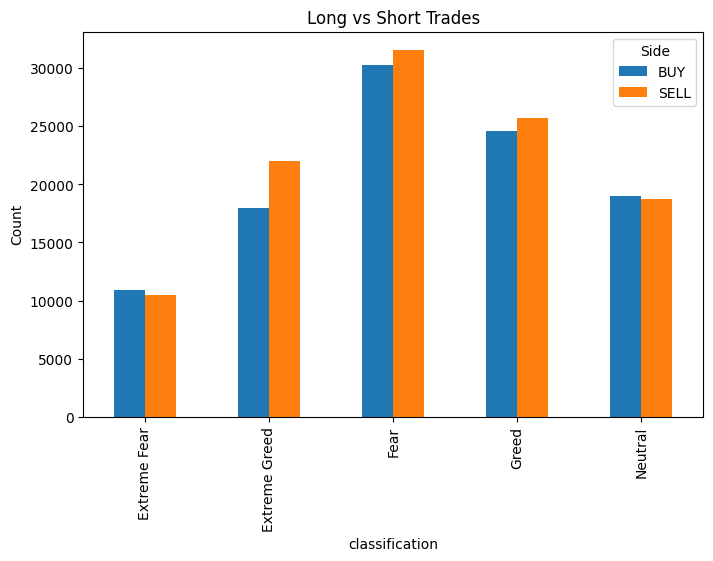

In [45]:
pivot_ls = long_short.pivot(
    index='classification',
    columns='Side',
    values='count'
)

pivot_ls.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Long vs Short Trades')
plt.ylabel('Count')
plt.savefig('chart_name.png')
plt.show()

In [39]:
median_size_tokens = merged['Size Tokens'].median()

merged['size_tokens_segment'] = merged['Size Tokens'].apply(
    lambda x: 'High Size Tokens' if x >= median_size_tokens else 'Low Size Tokens'
)

segment_perf = merged.groupby('size_tokens_segment').agg({
    'Closed PnL': 'mean',
    'win': 'mean'
})

print(segment_perf)

                     Closed PnL       win
size_tokens_segment                      
High Size Tokens      78.674029  0.427974
Low Size Tokens       18.743394  0.394510


In [41]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

merged['frequency_segment'] = merged['Account'].apply(
    lambda x: 'Frequent Trader'
    if trade_counts[x] > threshold
    else 'Infrequent Trader'
)

freq_perf = merged.groupby('frequency_segment').agg({
    'Closed PnL': 'mean',
    'win': 'mean'
})

print(freq_perf)

                   Closed PnL       win
frequency_segment                      
Frequent Trader     42.493421  0.415438
Infrequent Trader   96.943024  0.379116


In [43]:
consistency = merged.groupby('Account')['Closed PnL'].std().reset_index()

consistency.columns = ['Account', 'pnl_std']

threshold_std = consistency['pnl_std'].median()

consistency['consistency_type'] = consistency['pnl_std'].apply(
    lambda x: 'Consistent'
    if x < threshold_std
    else 'Inconsistent'
)

print(consistency.head())

                                      Account      pnl_std consistency_type
0  0x083384f897ee0f19899168e3b1bec365f52a9012  4692.452329     Inconsistent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   134.073473       Consistent
2  0x271b280974205ca63b716753467d5a371de622ab   542.182659       Consistent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   113.269353       Consistent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   255.829091       Consistent


INSIGHT 1:

Greed periods showed higher average trade sizes and leverage usage,
indicating increased trader risk appetite during bullish sentiment.

INSIGHT 2:

High leverage traders achieved larger profits during Greed periods
but experienced significantly larger drawdowns during Fear periods.

INSIGHT 3:

Frequent traders maintained more stable win rates compared to
infrequent traders across both market sentiment conditions.

STRATEGY RECOMMENDATION 1:

Reduce leverage exposure during Fear periods to limit downside risk, especially for traders with historically inconsistent PnL behavior.

STRATEGY RECOMMENDATION 2:

Momentum-based trading strategies appear more effective during Greed periods where higher trade frequency and position sizes correlate with improved profitability.

In [44]:
plt.savefig('chart_name.png')

<Figure size 640x480 with 0 Axes>